<p style="font-size:18px;">
This is to evaluate the approach of
<a href="https://www.youtube.com/redirect?event=video_description&redir_token=QUFFLUhqbUo5RXRNaEpoY3VaZnREMDdwcTRBc2VXTkZaZ3xBQ3Jtc0trNzNpSGs0amExX1RPYjVVMWtpcUpKejl1LTZoV2FPazY2SmxHNWIySTlSYXAyVWJqY0lvcFFyeS1JTy02N1hSTGJFMmlhcXFTVmtnTmpzankwNV83NWc5N094UFJHYU9jWmRfb09jLVZNRXM4RGpaOA&q=https%3A%2F%2Fwww.jmlr.org%2Fpapers%2Fvolume3%2Fbengio03a%2Fbengio03a.pdf&v=TCH_1BHY58I">
Bengio et al. 2003 MLP language model paper
</a>
on different dataset
</p>


## Build Dataset 

In [1]:
import torch 
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [13]:
names = open('names.txt', 'r').read().split()
names[:3]

['emma', 'olivia', 'ava']

In [27]:
G

In [37]:
block_size = 3
X, Y = [], []

for w in names[:3]: 
    print(w)
    context = [0] * block_size # initial dots, since we start by padding of dots
    for ch in w + '.': 
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print(''.join(itos[i] for i in context),'-->',ch)
        context = context[1:] + [ix] # Sliding window
        
X = torch.tensor(X) 
Y = torch.tensor(Y)

emma
... --> e
..e --> m
.em --> m
emm --> a
mma --> .
olivia
... --> o
..o --> l
.ol --> i
oli --> v
liv --> i
ivi --> a
via --> .
ava
... --> a
..a --> v
.av --> a
ava --> .


In [41]:
X.dtype, Y.dtype

(torch.int64, torch.int64)

In [42]:
X.shape, Y.shape

(torch.Size([16, 3]), torch.Size([16]))

<b> Three names with 16 examples for prediction

In [51]:
C = torch.randn((27,2)) # 27 Characters of embedding matrix with 2 dimensions
C.shape

torch.Size([27, 2])

<b> This embedding matrix store the embedding of each character of our dataset, represented with two dimension. The more dimensions the more complex and better representation of data

In [59]:
C[5] # same as F.one_hot(5) @ C

tensor([ 0.9300, -0.5645])

In [60]:
F.one_hot(torch.tensor(5), num_classes=27).float() @ C # since C is float 

tensor([ 0.9300, -0.5645])

In [95]:
C[[0, 0, 5]] # This means we got the embedding of two 0, 0, 5

tensor([[-2.0713,  0.1936],
        [-2.0713,  0.1936],
        [ 0.9300, -0.5645]])

In [79]:
print(f"C[X] shape is {C[X].shape}, X shape:{X.shape}")

C[:3]

C[X] shape is torch.Size([16, 3, 2]), X shape:torch.Size([16, 3])


tensor([[-2.0713,  0.1936],
        [ 0.1501,  0.1914],
        [-0.6447, -0.5697]])

<b> It added two dimensions with size on top of for X

In [96]:
X[3]

tensor([ 5, 13, 13])

In [97]:
C[X[3]]

tensor([[ 0.9300, -0.5645],
        [ 0.6308,  0.6029],
        [ 0.6308,  0.6029]])

```markdonw 
tensor([[ 0.9300, -0.5645], --> This is X[3][0] or C[5] 
        [ 0.6308,  0.6029], --> This is X[3][1] or C[13]
        [ 0.6308,  0.6029]]) --> This is X[3][2] or C[13]
        
So, instead of each character is represented with X[3] --> torch.tensor([5, 13, 13]) 
Each element instead is translated into embedding of size 2, so we add another dimension. 
So it becomes from (3, 1) to (3, 2), if we had many examples like shape(13, 3) which means
thirteen rows, each row have 3 columns, each column represents the three characters that we to predict afterwards.


It becomes (13, 3, 2) Each column entry for the 3 columns becomes 2D istead of a scaler value.

```

###  Building the hidden layer

In [99]:
emb = C[X]
emb.shape

torch.Size([16, 3, 2])

In [101]:
W1 = torch.randn(6, 100) 
b1 = torch.randn(100)

<p style="font-size:16px;"><b> Because (3x2) is flattened into 6, and that is the input to the neural network with 100 neurons</b></p>

### Flatten the dimensions for multiplication 

<p style="font-size:18px;"> We are sure that the matrix multiplication will not work out, becaues (3, 2) cannot be multiplied, however there are several ways to do that</p>

In [105]:
try: 
    emb @ W + 1
except: 
    print("Not Possible")
    

Not Possible


In [108]:
# First way
emb[:, 0, :] # --> This First Column 

tensor([[-2.0713,  0.1936],
        [-2.0713,  0.1936],
        [-2.0713,  0.1936],
        [ 0.9300, -0.5645],
        [ 0.6308,  0.6029],
        [-2.0713,  0.1936],
        [-2.0713,  0.1936],
        [-2.0713,  0.1936],
        [-0.4924, -0.0372],
        [-0.8045, -0.1740],
        [ 0.9992,  1.2733],
        [ 0.1251,  1.5947],
        [-2.0713,  0.1936],
        [-2.0713,  0.1936],
        [-2.0713,  0.1936],
        [ 0.1501,  0.1914]])

In [114]:
torch.cat((emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]), 1) # Along the column dimension

tensor([[-2.0713,  0.1936, -2.0713,  0.1936, -2.0713,  0.1936],
        [-2.0713,  0.1936, -2.0713,  0.1936,  0.9300, -0.5645],
        [-2.0713,  0.1936,  0.9300, -0.5645,  0.6308,  0.6029],
        [ 0.9300, -0.5645,  0.6308,  0.6029,  0.6308,  0.6029],
        [ 0.6308,  0.6029,  0.6308,  0.6029,  0.1501,  0.1914],
        [-2.0713,  0.1936, -2.0713,  0.1936, -2.0713,  0.1936],
        [-2.0713,  0.1936, -2.0713,  0.1936, -0.4924, -0.0372],
        [-2.0713,  0.1936, -0.4924, -0.0372, -0.8045, -0.1740],
        [-0.4924, -0.0372, -0.8045, -0.1740,  0.9992,  1.2733],
        [-0.8045, -0.1740,  0.9992,  1.2733,  0.1251,  1.5947],
        [ 0.9992,  1.2733,  0.1251,  1.5947,  0.9992,  1.2733],
        [ 0.1251,  1.5947,  0.9992,  1.2733,  0.1501,  0.1914],
        [-2.0713,  0.1936, -2.0713,  0.1936, -2.0713,  0.1936],
        [-2.0713,  0.1936, -2.0713,  0.1936,  0.1501,  0.1914],
        [-2.0713,  0.1936,  0.1501,  0.1914,  0.1251,  1.5947],
        [ 0.1501,  0.1914,  0.1251,  1.5

In [115]:
torch.cat((emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]), 1).shape

torch.Size([16, 6])

We concatenate first column along the second along the third, and since every column is two points, stacked across the columns becomes 6. 

In [144]:
# Second way is torch.unbind

In [157]:
# Returns a list of tensors splited by columns as s
torch.unbind(emb, 1)[0] # Same as emb[:, 0, :] 
torch.unbind(emb, 1)[1] # Same as emb[:, 1, :] 
torch.unbind(emb, 1)[2] # Same as emb[:, 2, :] 

tensor([[-2.0713,  0.1936],
        [-2.0713,  0.1936],
        [-2.0713,  0.1936],
        [ 0.9300, -0.5645],
        [ 0.6308,  0.6029],
        [-2.0713,  0.1936],
        [-2.0713,  0.1936],
        [-2.0713,  0.1936],
        [-0.4924, -0.0372],
        [-0.8045, -0.1740],
        [ 0.9992,  1.2733],
        [ 0.1251,  1.5947],
        [-2.0713,  0.1936],
        [-2.0713,  0.1936],
        [-2.0713,  0.1936],
        [ 0.1501,  0.1914]])

In [188]:
torch.any((torch.cat(torch.unbind(emb, 1), 1) == torch.cat((emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]), 1)))

tensor(True)

Any will return if any value is false, and since all values match, it returns True

In [190]:
emb.view(16, 6)

tensor([[-2.0713,  0.1936, -2.0713,  0.1936, -2.0713,  0.1936],
        [-2.0713,  0.1936, -2.0713,  0.1936,  0.9300, -0.5645],
        [-2.0713,  0.1936,  0.9300, -0.5645,  0.6308,  0.6029],
        [ 0.9300, -0.5645,  0.6308,  0.6029,  0.6308,  0.6029],
        [ 0.6308,  0.6029,  0.6308,  0.6029,  0.1501,  0.1914],
        [-2.0713,  0.1936, -2.0713,  0.1936, -2.0713,  0.1936],
        [-2.0713,  0.1936, -2.0713,  0.1936, -0.4924, -0.0372],
        [-2.0713,  0.1936, -0.4924, -0.0372, -0.8045, -0.1740],
        [-0.4924, -0.0372, -0.8045, -0.1740,  0.9992,  1.2733],
        [-0.8045, -0.1740,  0.9992,  1.2733,  0.1251,  1.5947],
        [ 0.9992,  1.2733,  0.1251,  1.5947,  0.9992,  1.2733],
        [ 0.1251,  1.5947,  0.9992,  1.2733,  0.1501,  0.1914],
        [-2.0713,  0.1936, -2.0713,  0.1936, -2.0713,  0.1936],
        [-2.0713,  0.1936, -2.0713,  0.1936,  0.1501,  0.1914],
        [-2.0713,  0.1936,  0.1501,  0.1914,  0.1251,  1.5947],
        [ 0.1501,  0.1914,  0.1251,  1.5

`view` can reshape, you can specify the shape of the tensor. However the shaping should match the original, since we specified the second to be 6 and (3, 2), can be it worked. 

However, `view` has extra benefit that it doesn't modify in the store the other two methods, take extra space, for assigning and creation, view is more efficient since every tensor is stored in RAM in a sequence, and the way we respresented is what differs, so view, only change the repsentations, it doesn't do anything in the ram. Unlike the other methods. 

You can read about it more [Pytorch Internals](https://blog.ezyang.com/2019/05/pytorch-internals/)

In [192]:
try:
    emb.view(16, 5)
except: 
    print("Can't match dimensions")

Can't match dimensions


In [193]:
emb.view(-1, 6) # -1 will choose the rest to be the correct dimension that works for that reshape

tensor([[-2.0713,  0.1936, -2.0713,  0.1936, -2.0713,  0.1936],
        [-2.0713,  0.1936, -2.0713,  0.1936,  0.9300, -0.5645],
        [-2.0713,  0.1936,  0.9300, -0.5645,  0.6308,  0.6029],
        [ 0.9300, -0.5645,  0.6308,  0.6029,  0.6308,  0.6029],
        [ 0.6308,  0.6029,  0.6308,  0.6029,  0.1501,  0.1914],
        [-2.0713,  0.1936, -2.0713,  0.1936, -2.0713,  0.1936],
        [-2.0713,  0.1936, -2.0713,  0.1936, -0.4924, -0.0372],
        [-2.0713,  0.1936, -0.4924, -0.0372, -0.8045, -0.1740],
        [-0.4924, -0.0372, -0.8045, -0.1740,  0.9992,  1.2733],
        [-0.8045, -0.1740,  0.9992,  1.2733,  0.1251,  1.5947],
        [ 0.9992,  1.2733,  0.1251,  1.5947,  0.9992,  1.2733],
        [ 0.1251,  1.5947,  0.9992,  1.2733,  0.1501,  0.1914],
        [-2.0713,  0.1936, -2.0713,  0.1936, -2.0713,  0.1936],
        [-2.0713,  0.1936, -2.0713,  0.1936,  0.1501,  0.1914],
        [-2.0713,  0.1936,  0.1501,  0.1914,  0.1251,  1.5947],
        [ 0.1501,  0.1914,  0.1251,  1.5

## Exploring Neural Network

In [355]:
emb = emb.view(-1, 6)

In [357]:
W1 = torch.randn(6, 100) 
b1 = torch.randn(100)

In [358]:
h= torch.tanh(emb @ W1 + b1)

In [359]:
h.shape

torch.Size([16, 100])

In [360]:
W2 = torch.randn(100, 27)
b2 = torch.randn(27) 

In [361]:
logits = N1 @ W2 + b2

In [362]:
counts = logits.exp()

In [363]:
props = counts / counts.sum(1, keepdims=True)

In [364]:
-props[torch.arange(emb.shape[0]), Y].log().mean()

tensor(inf)

<p style="font-size:16px;">Because we got $e^{x}$ approach infinity as x gets bigger And $log({inf}) = inf$</p>

In [365]:
logits = logits - logits.max(dim=1, keepdim=True).values
 # This will normalize to avoid inf. between - numbers up to 0. 

In [366]:
counts = logits.exp() 

In [367]:
props = counts / counts.sum(1, keepdims=True)

In [368]:
-props[torch.arange(emb.shape[0]), Y].log().mean() 

tensor(46.8711)

tensor(46.8711)

In [371]:
output = F.cross_entropy(logits, Y)
output

tensor(46.8711)

<b style="color: red;">Same Result That is what cross_entropy does internally.</b>


<b>Why Should We Only Use Cross Entropy? 
    
    1. One We created three intermediate variables, counts, logits, and Loss. That is very inefficient.
    cross entropy would use something called fused kernel, to cluster up all these operations and do it very           efficiently. 
    
    2. The backward pass is much faster, analytically and mathematically, because, in mathematics you could like take the derivative of the exp, then the sum, and every operations, or one for the whole operation, like tanh(x) is composed of many operations, but a known derivative is after simplification like 1 - tanh(x)^2
    
    3. It would normalize to avoid floating number infinity, as we saw earlier, because very high numbers with e, lead to every big number, how very negative numbers would lead to zero, and we only care about the ratio of these numbers, since in the end we get a probability, it doesn't matter if we offset(add or subtract) any number). There are numbers that are more numerically stable. 


### Building Neural Network With Backward Pass

In [416]:
block_size = 3
X, Y = [], []
for w in names: 
    context = [0] * block_size # initial dots, since we start by padding of dots
    for ch in w + '.': 
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
#         print(''.join(itos[i] for i in context),'-->',ch)
        context = context[1:] + [ix] # Sliding window
        
X = torch.tensor(X) 
Y = torch.tensor(Y)
X.shape, Y.shape

(torch.Size([228146, 3]), torch.Size([228146]))

In [459]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [418]:
sum(p.nelement() for p in parameters) # Numbers of parameters in the model

3481

In [419]:
for p in parameters: 
    p.requires_grad = True

In [404]:
for _ in range(100):
    # Forward
    emb = C[X]
    emb = emb.view(-1, 6)
    h = torch.tanh(emb @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y)
    if _ % 10 == 0: 
        print(loss.item())
    # Backward
    for p in parameters: 
        p.grad = None
    loss.backward()
    #update
    for p in parameters:
        p.data += -0.01 * p.grad

3.790950298309326
3.772000789642334
3.753570795059204
3.735637664794922
3.71817946434021
3.7011775970458984
3.6846141815185547
3.6684720516204834
3.652735471725464
3.63739013671875


<p style="font-size:16px;">The loss can never be zero, due the fundamental nature of the problem, because this names, which common patterns occur, the most obvious one would be the start ...[a, b, c, d], naturally we would have the start would be more than one character for many names in the dataset, so the model can't reach 100% probability for all the possibilities, because we have different possibilities for the exact same input. 

### Mini Batch

<p style="font-size:16px;">The previous forward backward pass is called <b>Batch Gradient Descent</b>, while the vector gradient direction is the most accurate it is very slow, because we update after many example above 200k, which is very inefficient, and also all operations should exist in the memory, which is limited on a very large Neural Networks. <b>Mini Batch</b> is a good options we update each number of batches, it is less accurate, but over on many epochs, it reaches the same results. 

In [407]:
torch.randint(0, X.shape[0], (32,)) # We choose 32 random rows from 0 to 228,146 examples

tensor([  3409, 144802,  49623,  78112,  38375, 161015,  92778, 183644, 202140,
         48567, 167116,  84458,  75854,  88449,  44845, 116131,  87386, 192961,
        143717,  19542, 108937,  37864,  16008, 140945, 112373, 141659,  50496,
        131365, 169515,  21651,  71777, 129425])

In [440]:
for _ in range(1000):
    # Minibatch
    ixs = torch.randint(0, X.shape[0], (32,))
    # Forward
    emb = C[X[ixs]]
    emb = emb.view(-1, 6)
    h = torch.tanh(emb @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ixs])
    if _ % 100 == 0: 
        print(f"Iteration: {_}, Loss: {loss.item()}")
    # Backward
    for p in parameters: 
        p.grad = None
    loss.backward()
    #update
    for p in parameters:
        p.data += -0.01 * p.grad

Iteration: 0, Loss: 2.597398042678833
Iteration: 100, Loss: 2.5581986904144287
Iteration: 200, Loss: 2.8019559383392334
Iteration: 300, Loss: 2.480360984802246
Iteration: 400, Loss: 2.6257452964782715
Iteration: 500, Loss: 3.0755465030670166
Iteration: 600, Loss: 2.6129865646362305
Iteration: 700, Loss: 2.3117105960845947
Iteration: 800, Loss: 2.649815082550049
Iteration: 900, Loss: 2.5743601322174072


In [442]:
# Full Batch
emb = C[X]
emb = emb.view(-1, 6)
h = torch.tanh(emb @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y)
print(loss.item())

2.5346016883850098


### Choosing a Learning Rate 

Instead of doing `torch.linspace(0.001, 1, 1000)` Separated linearly is not logically because we are trying values
too much close too each other, however in power of 10, it is separated more equally no clustered, and 10 difference, is a better approximate and a better space to test learning rates. 

In [461]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre # from 0.001 to 1
lrs[-10:]

tensor([0.9397, 0.9462, 0.9528, 0.9594, 0.9660, 0.9727, 0.9795, 0.9863, 0.9931,
        1.0000])

In [479]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters: 
    p.requires_grad = True

In [488]:
lri = []
lossi = []
for i in range(1000):
    # Minibatch
    ixs = torch.randint(0, X.shape[0], (32,))
    
    # Forward
    emb = C[X[ixs]]
    emb = emb.view(-1, 6)
    h = torch.tanh(emb @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ixs])
        
    # Backward
    for p in parameters: 
        p.grad = None
    loss.backward()
    
    #update
    lr = lrs[i]
    for p in parameters:
        p.data += -lr * p.grad
    
    # track loss
    lri.append(lre[i])
    lossi.append(loss.item())

2.6185336112976074


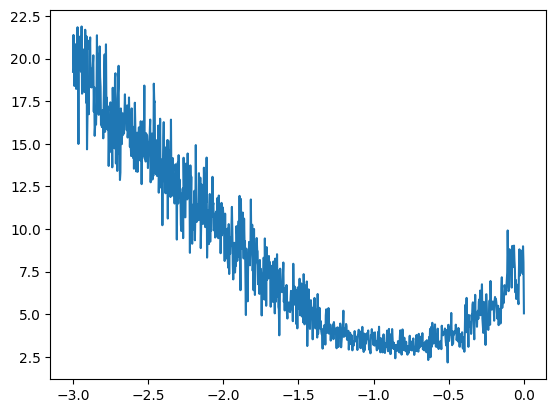

In [481]:
plt.plot(lri, lossi)

In [487]:
10**-1

0.1

#### Training With Optimal Learning Rate

In [635]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters: 
    p.requires_grad = True

In [642]:
lr = 0.1
for _ in range(1000):
    # Minibatch
    ixs = torch.randint(0, X.shape[0], (32,))
    # Forward
    emb = C[X[ixs]]
    emb = emb.view(-1, 6)
    h = torch.tanh(emb @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ixs])
    if _ % 100 == 0: 
        print(f"Iteration: {_}, Loss: {loss.item()}")
    # Backward
    for p in parameters: 
        p.grad = None
    loss.backward()
    #update
    for p in parameters:
        p.data += -lr * p.grad

Iteration: 0, Loss: 2.1757888793945312
Iteration: 100, Loss: 2.1772665977478027
Iteration: 200, Loss: 2.687593698501587
Iteration: 300, Loss: 2.4002504348754883
Iteration: 400, Loss: 2.4074065685272217
Iteration: 500, Loss: 2.5310797691345215
Iteration: 600, Loss: 2.5394434928894043
Iteration: 700, Loss: 2.838772773742676
Iteration: 800, Loss: 2.756260871887207
Iteration: 900, Loss: 2.300300121307373


In [643]:
# Full Batch
emb = C[X]
emb = emb.view(-1, 6)
h = torch.tanh(emb @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y)
print(loss.item())

2.561565399169922


#### Now Learning Rate Decay
    we lower it by 10x, because now we make small
    changes, since are close, instead of making big changes and we overshoot, so take 
    lower steps, 
if you run the above cells multiple time.
**you are going to notice that the loss of the full batch is plateaued, so we make it more smaller**

In [680]:
lr = 0.01 # Lower it by 10x
for _ in range(1000):
    # Minibatch
    ixs = torch.randint(0, X.shape[0], (32,))
    # Forward
    emb = C[X[ixs]]
    emb = emb.view(-1, 6)
    h = torch.tanh(emb @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ixs])
    if _ % 100 == 0: 
        print(f"Iteration: {_}, Loss: {loss.item()}")
    # Backward
    for p in parameters: 
        p.grad = None
    loss.backward()
    #update
    for p in parameters:
        p.data += -lr * p.grad

Iteration: 0, Loss: 2.743797540664673
Iteration: 100, Loss: 2.5135719776153564
Iteration: 200, Loss: 2.4255905151367188
Iteration: 300, Loss: 2.482896089553833
Iteration: 400, Loss: 2.4300785064697266
Iteration: 500, Loss: 2.062166452407837
Iteration: 600, Loss: 2.3126108646392822
Iteration: 700, Loss: 2.4419617652893066
Iteration: 800, Loss: 2.6207828521728516
Iteration: 900, Loss: 2.0740346908569336


In [681]:
# Full Batch
emb = C[X]
emb = emb.view(-1, 6)
h = torch.tanh(emb @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y)
print(loss.item())

2.4523797035217285


<span style="color: rgb(0, 70, 160); font-weight: bold; font-size: 15px;">
It is lower, but how do we really evaluate our model, this is not a generalizable, way 
    we could have for say a bigger model, how do we really now it is better?
</span>


### How do we generalize? 
     Generalizing means,the model is able to deal with scenarios it haven't seen before. 
     
     In this example, it would output the same letter each time, not able to generate 
     new sounding names, that match our dataset, and that is the goal of this series
     actually. And even if we measured the loss on new withhold, part of the data, 
     it would be high, because the model haven't captured the patterns in names, and 
     since this is a new set of names, that the model haven't seen. It is most likely to
     perform worse, than the train loss.

#### Train, Validation, Test Split

In [683]:
names = open('names.txt', 'r').read().splitlines() 

In [690]:
chars = sorted(list(set(''.join(names))))
chars.insert(0, '.')
stoi = {s: i for i, s in enumerate(chars)}
itos = {i:s for s, i in stoi.items()}

In [684]:
import random
import torch
import torch.nn.functional as F

random.seed(42)

g = torch.Generator().manual_seed(2147483647)

In [686]:
random.shuffle(names)

n = len(names)
n

32033

In [698]:
n_train = int(0.8 * n)
n_dev   = int(0.1 * n)

n, n_train, n_dev

(32033, 25626, 3203)

In [951]:
def build_dataset(names):
    block_size = 3
    X, Y = [], []
    for w in names: 
        context = [0] * block_size # initial dots, since we start by padding of dots
        for ch in w + '.': 
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # Sliding window

    X = torch.tensor(X) 
    Y = torch.tensor(Y)
    return X, Y

In [952]:
x_train, y_train = build_dataset(names[:n_train]) # 0.8
x_dev, y_dev = build_dataset(names[n_train:n_train+n_dev]) # 0.1
x_test, y_test  = build_dataset(names[n_train+n_dev:]) # 0.1

len(x_train), len(x_dev), len(x_test)

(182473, 22827, 22846)

In [704]:
len(x_train) + len(x_dev) + len(x_test) == len(build_dataset(names)[0])

True

In [728]:
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters: 
    p.requires_grad = True

In [736]:
lr = 0.01 
for _ in range(1000):
    # Minibatch
    ixs = torch.randint(0, x_train.shape[0], (32,))
    # Forward
    emb = C[x_train[ixs]]
    emb = emb.view(-1, 6)
    h = torch.tanh(emb @ W1 + b1)
    logits = h @ W2 + b2
    train_loss = F.cross_entropy(logits, y_train[ixs])
    # Backward
    for p in parameters: 
        p.grad = None
    train_loss.backward()
    #update
    for p in parameters:
        p.data += -lr * p.grad
        
    if _ % 100 == 0: 
        emb = C[x_dev]
        emb = emb.view(-1, 6)
        h = torch.tanh(emb @ W1 + b1)
        logits = h @ W2 + b2
        val_loss = F.cross_entropy(logits, y_dev)
        
        print("Iteration: {:4d} | Training Loss: {:8.6f} | Validation Loss: {:8.5f}".format(_, train_loss, val_loss))



Iteration:    0 | Training Loss: 2.553953 | Validation Loss:  2.44191
Iteration:  100 | Training Loss: 2.620867 | Validation Loss:  2.43940
Iteration:  200 | Training Loss: 2.455929 | Validation Loss:  2.44153
Iteration:  300 | Training Loss: 2.293828 | Validation Loss:  2.44195
Iteration:  400 | Training Loss: 2.500679 | Validation Loss:  2.44232
Iteration:  500 | Training Loss: 2.462434 | Validation Loss:  2.44087
Iteration:  600 | Training Loss: 2.426989 | Validation Loss:  2.43923
Iteration:  700 | Training Loss: 2.378246 | Validation Loss:  2.43674
Iteration:  800 | Training Loss: 2.375602 | Validation Loss:  2.43684
Iteration:  900 | Training Loss: 2.380306 | Validation Loss:  2.43920


<span style="color: rgb(0, 70, 160); font-weight: bold; font-size: 15px;"> The model is not able to achieve lower loss, it is under fitting, meaning we have slightly higher bias, we could increase the complexity of the model, by having bigger Neural Network

</span>


#### Increasing the model complexity

In [756]:
# Reinitialize the model with higher neurons
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 300), generator=g)
b1 = torch.randn(300, generator=g)
W2 = torch.randn((300, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters: 
    p.requires_grad = True

sum(p.nelement() for p in parameters) # Numbers of parameters in the model

10281

In [776]:
lr = 0.01 
stepi = [] # number of steps
lossi = []
for i in range(30000):
    # Minibatch
    ixs = torch.randint(0, x_train.shape[0], (32,))
    # Forward
    emb = C[x_train[ixs]]
    emb = emb.view(-1, 6)
    h = torch.tanh(emb @ W1 + b1)
    logits = h @ W2 + b2
    train_loss = F.cross_entropy(logits, y_train[ixs])
    # Backward
    for p in parameters: 
        p.grad = None
    train_loss.backward()
    #update
    for p in parameters:
        p.data += -lr * p.grad
        
    if i % 100 == 0: 
        emb = C[x_dev]
        emb = emb.view(-1, 6)
        h = torch.tanh(emb @ W1 + b1)
        logits = h @ W2 + b2
        val_loss = F.cross_entropy(logits, y_dev)
        stepi.append(i)
        lossi.append(val_loss.item())
        #print("Iteration: {:4d} | Training Loss: {:8.6f} | Validation Loss: {:8.5f}".format(i, train_loss, val_loss))


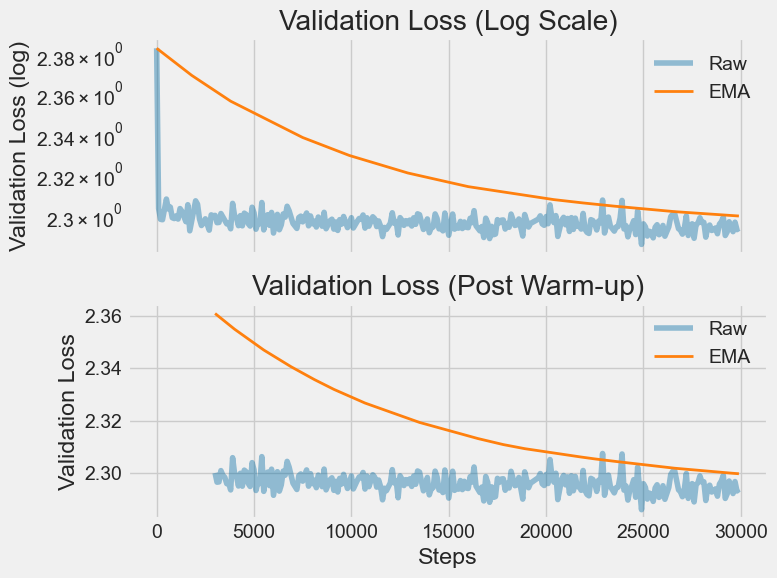

In [785]:
import numpy as np
plt.style.use("tableau-colorblind10")


stepi = np.array(stepi)
lossi = np.array(lossi)

assert len(stepi) == len(lossi)

# ---------------------------
# EMA Exponential Moving Average 
# ---------------------------
alpha = 0.01
ema = np.empty_like(lossi)
ema[0] = lossi[0]
for i in range(1, len(lossi)):
    ema[i] = alpha * lossi[i] + (1 - alpha) * ema[i - 1]

# ---------------------------
# Warmup handling (SAFE)
# ---------------------------
warmup = min(500, len(stepi) // 10)  # adaptive

# ---------------------------
# Plot
# ---------------------------
fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# Top: full curve (log)
axs[0].plot(stepi, lossi, alpha=0.4, label="Raw")
axs[0].plot(stepi, ema, linewidth=2, label="EMA")
axs[0].set_yscale("log")
axs[0].set_ylabel("Validation Loss (log)")
axs[0].set_title("Validation Loss (Log Scale)")
axs[0].legend()

# Bottom: post-warmup
axs[1].plot(stepi[warmup:], lossi[warmup:], alpha=0.4, label="Raw")
axs[1].plot(stepi[warmup:], ema[warmup:], linewidth=2, label="EMA")
axs[1].set_ylabel("Validation Loss")
axs[1].set_xlabel("Steps")
axs[1].set_title("Validation Loss (Post Warm-up)")
axs[1].legend()

plt.tight_layout()
plt.show()


In [780]:
emb = C[x_dev]
emb = emb.view(-1, 6)
h = torch.tanh(emb @ W1 + b1)
logits = h @ W2 + b2
val_loss = F.cross_entropy(logits, y_dev)
print("Training Loss: {:8.6f} | Validation Loss: {:8.5f}".format(train_loss, val_loss))

Training Loss: 2.123044 | Validation Loss:  2.29205


Now Maybe what is hindering the performance, is not Neural Network, maybe the neural network, did it is best
to have a good embeddings, but usually 2 per character is little low to generalize to how naming works. 

So we try a little larger embeddings size, it is gonna represents naming in a better way. 


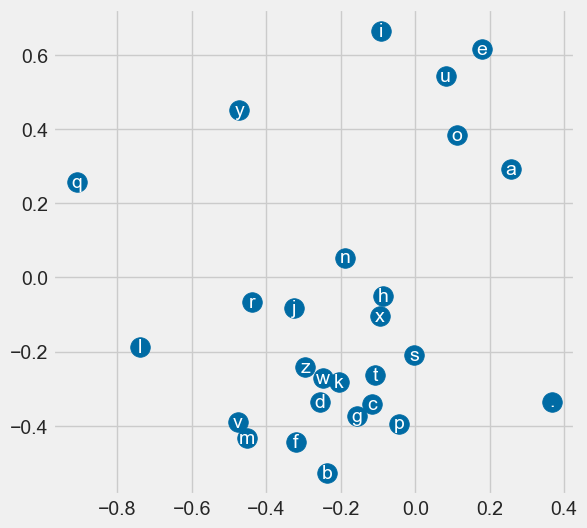

In [793]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(6,6))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')



<b> My intuition, that vowels live closer in their embeddings, I don't know why, maybe, because they appear after
    different characters, so they got the same embeddings, or their soundings, q on far left, pretty uncommon, and doesn't appear with many characters. 

#### Increasing the embedding size

In [796]:
C = torch.randn((27, 10), generator=g) # 10 Embeddings per character
W1 = torch.randn((30, 200), generator=g) # 3 x 10
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters: 
    p.requires_grad = True

sum(p.nelement() for p in parameters) # Numbers of parameters in the model

11897

In [812]:
subset = X[:2, :]
C[subset].shape

torch.Size([2, 3, 10])

Because the columns are our previous letters, and we have 3 as input, and predict the fourth. 
So for each input we have 3 columns and the order matters, for each column instead of 2 embeddings values, we have
10 to represent it each letter, and after it flats out, we are going to have 30, however, when backpropagation happens, it is going to update each letter embedding accordingly, because it keeps track of the operations that happens. 

I was really confused about letter's and words as features, but at the end of the day, it doesn't matter, we have input(features) and output. Features are columns, in tabular data that could be normal features, in image, they could be pixels, in text, they could be either words or letters like this case. And each one get's an embedding of some size, one more thing it could also be that we have entire vocabulary of words, and use words as input or tokens, what ever, and the number of tokens is just columns, and block is size is all previous characters, so it could be any number as well, but can the neural network keep up, that is why we introduce transformers architecture, because the bottleneck was the NN architecture it self, it process every thing as one input of dimensions. I asked claude and here it is answer for reference. 
[claudechat](https://claude.ai/share/c5ce2e0d-0517-4d73-9475-7f3b18c5bfdc)

In [813]:
lr = 0.01 
stepi = [] # number of steps
lossi = []

In [882]:
def train_nn(
    params,
    x_train,
    y_train,
    x_dev,
    y_dev,
    steps=150_000,
    batch_size=64,
    log_every=500,
):
    C, W1, b1, W2, b2 = params
    parameters = [C, W1, b1, W2, b2]

    stepi = []
    train_lossi = []
    val_lossi = []

    def forward(x):
        emb = C[x]
        emb = emb.view(x.shape[0], -1)
        h = torch.tanh(emb @ W1 + b1)
        logits = h @ W2 + b2
        return logits

    for i in range(steps):
        # minibatch
        ixs = torch.randint(0, x_train.shape[0], (batch_size,))
        logits = forward(x_train[ixs])
        train_loss = F.cross_entropy(logits, y_train[ixs])

        # backward
        for p in parameters:
            p.grad = None
        train_loss.backward()

        # LR schedule 
        lr = 0.01 if i < 100_000 else 0.001

        with torch.no_grad():
            for p in parameters:
                p -= lr * p.grad

        # logging
        if i % log_every == 0:
            with torch.no_grad():
                train_logits_eval = forward(x_train[:512])
                train_loss_eval = F.cross_entropy(
                    train_logits_eval, y_train[:512]
                )

                val_logits = forward(x_dev)
                val_loss = F.cross_entropy(val_logits, y_dev)

            stepi.append(i)
            train_lossi.append(train_loss_eval.item())
            val_lossi.append(val_loss.item())

    return stepi, train_lossi, val_lossi


In [873]:
stepi, lossi = train_nn(parameters, x_train, y_train, x_dev, y_dev)

In [ ]:
import numpy as np
plt.style.use("tableau-colorblind10")


stepi = np.array(stepi)
lossi = np.array(lossi)

assert len(stepi) == len(lossi)

# ---------------------------
# EMA Exponential Moving Average 
# ---------------------------
alpha = 0.01
ema = np.empty_like(lossi)
ema[0] = lossi[0]
for i in range(1, len(lossi)):
    ema[i] = alpha * lossi[i] + (1 - alpha) * ema[i - 1]

# ---------------------------
# Warmup handling (SAFE)
# ---------------------------
warmup = min(500, len(stepi) // 10)  # adaptive

# ---------------------------
# Plot
# ---------------------------
fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# Top: full curve (log)
axs[0].plot(stepi, lossi, alpha=0.4, label="Raw")
axs[0].plot(stepi, ema, linewidth=2, label="EMA")
axs[0].set_yscale("log")
axs[0].set_ylabel("Validation Loss (log)")
axs[0].set_title("Validation Loss (Log Scale)")
axs[0].legend()

# Bottom: post-warmup
axs[1].plot(stepi[warmup:], lossi[warmup:], alpha=0.4, label="Raw")
axs[1].plot(stepi[warmup:], ema[warmup:], linewidth=2, label="EMA")
axs[1].set_ylabel("Validation Loss")
axs[1].set_xlabel("Steps")
axs[1].set_title("Validation Loss (Post Warm-up)")
axs[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
emb = C[x_train]
emb = emb.view(x_train.shape[0], -1)
h = torch.tanh(emb @ W1 + b1)
logits = h @ W2 + b2
val_loss = F.cross_entropy(logits, y_train)
print("Training Loss: {:8.6f} | Validation Loss: {:8.5f}".format(train_loss, lossi[-1]))

#### Grid Search

In [881]:
import itertools
import torch

embedding_dims = [10, 20]
hidden_dims = [100, 200]
batch_sizes = [32, 64, 128]

results = []


Running: emb=10, hidden=100, batch=32
final train: 2.1940 | final val: 2.3154 | gap: 0.1214

Running: emb=10, hidden=100, batch=64
final train: 2.1745 | final val: 2.3073 | gap: 0.1328

Running: emb=10, hidden=100, batch=128
final train: 2.1859 | final val: 2.3066 | gap: 0.1206

Running: emb=10, hidden=200, batch=32
final train: 2.1600 | final val: 2.3105 | gap: 0.1505

Running: emb=10, hidden=200, batch=64
final train: 2.1644 | final val: 2.3013 | gap: 0.1369

Running: emb=10, hidden=200, batch=128
final train: 2.1650 | final val: 2.3047 | gap: 0.1397

Running: emb=20, hidden=100, batch=32
final train: 2.1746 | final val: 2.3357 | gap: 0.1611

Running: emb=20, hidden=100, batch=64
final train: 2.1663 | final val: 2.3282 | gap: 0.1619

Running: emb=20, hidden=100, batch=128
final train: 2.1738 | final val: 2.3300 | gap: 0.1562

Running: emb=20, hidden=200, batch=32
final train: 2.2153 | final val: 2.4835 | gap: 0.2682

Running: emb=20, hidden=200, batch=64
final train: 2.2618 | final val: 2.4920 | gap: 0.2302

Running: emb=20, hidden=200, batch=128
final train: 2.2389 | final val: 2.5006 | gap: 0.2617


<b> Adding more dimensions is not helping, it is not generalizing well, we start to a bigger gap with higher dimensions, this key indication. 

#### Round 2

    Using different positional embeddings, so every character lives in it is own subspace

In [954]:
emb_dim = 10
hidden_dim = 200

# embeddings
C = torch.randn((27, emb_dim), generator=g, requires_grad=True)

# first hidden layer (untied positions)
W1_0 = torch.randn((emb_dim, hidden_dim), generator=g) * 0.1
W1_1 = torch.randn((emb_dim, hidden_dim), generator=g) * 0.1
W1_2 = torch.randn((emb_dim, hidden_dim), generator=g) * 0.1
b1   = torch.zeros(hidden_dim, requires_grad=True)

# second hidden layer
W2 = torch.randn((hidden_dim, hidden_dim), generator=g) * 0.1
b2 = torch.zeros(hidden_dim, requires_grad=True)

# output layer
W3 = torch.randn((hidden_dim, 27), generator=g) * 0.1
b3 = torch.zeros(27, requires_grad=True)

params = (C, W1_0, W1_1, W1_2, b1, W2, b2, W3, b3)

for p in params:
    p.requires_grad = True

In [953]:
def train_nn(
    params,
    x_train,
    y_train,
    x_dev,
    y_dev,
    steps=100_000,
    batch_size=32,
    log_every=500,
):
    C, W1_0, W1_1, W1_2, b1, W2, b2, W3, b3 = params
    parameters = list(params)

    stepi = []
    train_lossi = []
    val_lossi = []

    def forward(x):
        emb = C[x]          # (B, 3, emb_dim)
        e0, e1, e2 = emb[:, 0], emb[:, 1], emb[:, 2]

        h1 = (
            e0 @ W1_0 +
            e1 @ W1_1 +
            e2 @ W1_2 +
            b1
        )
        h1 = torch.relu(h1)

        h2 = h1 @ W2 + b2
        h2 = torch.relu(h2)

        logits = h2 @ W3 + b3
        return logits

    for i in range(steps):
        # minibatch
        ixs = torch.randint(0, x_train.shape[0], (batch_size,))
        logits = forward(x_train[ixs])
        train_loss = F.cross_entropy(logits, y_train[ixs])

        # backward
        for p in parameters:
            p.grad = None
        train_loss.backward()

        # LR schedule
        lr = 0.01 if i < 100_000 else 0.001

        # update
        with torch.no_grad():
            for p in parameters:
                p -= lr * p.grad

        # logging
        if i % log_every == 0:
            with torch.no_grad():
                train_logits_eval = forward(x_train[:512])
                train_loss_eval = F.cross_entropy(
                    train_logits_eval, y_train[:512]
                )

                val_logits = forward(x_dev)
                val_loss = F.cross_entropy(val_logits, y_dev)

            stepi.append(i)
            train_lossi.append(train_loss_eval.item())
            val_lossi.append(val_loss.item())

    return params, stepi, train_lossi, val_lossi


In [955]:
opt_params, stepi, train_lossi, val_lossi = train_nn(
    params,
    x_train,
    y_train,
    x_dev,
    y_dev,
    batch_size=64,
    steps=300_000
)

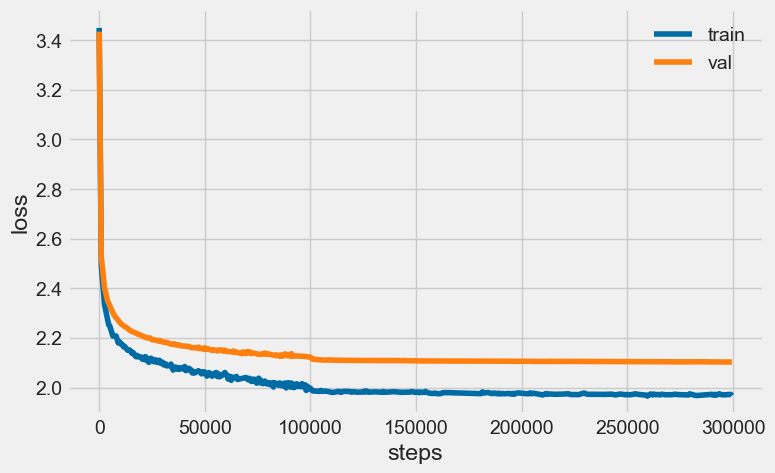

In [956]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(stepi[-1000:], train_lossi[-1000:], label="train")
plt.plot(stepi[-1000:], val_lossi[-1000:], label="val")
plt.xlabel("steps")
plt.ylabel("loss")
plt.legend()
plt.grid(True)
plt.show()


In [957]:
min(train_lossi), min(val_lossi)

(1.9656273126602173, 2.10209584236145)

### Generating Names Using Best Model 

In [958]:
assert block_size == 3
assert C.shape[1] == 10
assert W2.shape[0] == 200

In [960]:
# sampling
g = torch.Generator().manual_seed(2147483647 + 10)

C, W1_0, W1_1, W1_2, b1, W2, b2, W3, b3 = opt_params

for _ in range(30):

    out = []
    context = [0] * block_size  # block_size = 3

    while True:
        x = torch.tensor([context])   # (1, 3)
        emb = C[x]                    # (1, 3, emb_dim)

        e0 = emb[:, 0]                # (1, emb_dim)
        e1 = emb[:, 1]
        e2 = emb[:, 2]

        # first hidden layer (untied positions)
        h1 = (
            e0 @ W1_0 +
            e1 @ W1_1 +
            e2 @ W1_2 +
            b1
        )
        h1 = torch.relu(h1)

        # second hidden layer
        h2 = h1 @ W2 + b2
        h2 = torch.relu(h2)

        # output layer
        logits = h2 @ W3 + b3
        probs = F.softmax(logits, dim=1)

        ix = torch.multinomial(probs, num_samples=1, generator=g).item()

        context = context[1:] + [ix]
        out.append(ix)

        if ix == 0:
            break

    print(''.join(itos[i] for i in out))


carmahzaal.
hari.
kimri.
reety.
skanden.
jazonte.
delynn.
jarquis.
ramari.
chaiir.
kaleigh.
ham.
join.
quint.
suline.
liveni.
wazelo.
dearyn.
kai.
eveighan.
eddeli.
abette.
jastravarae.
benjiksyn.
paqlorose.
joodnica.
jerren.
kalla.
luco.
zoe.
